# 👤 Gender Classification — ML Pipeline
### A complete machine learning project that predicts gender based on physical features using four classification algorithms: Logistic Regression, Decision Tree, Naive Bayes, KNN, and SVM.

# 📦 1. Importing Required Libraries
### In this section we import all necessary Python libraries for data analysis, visualization, and machine learning.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Pipeline
from imblearn.pipeline import Pipeline

# 📂 2. Loading the Dataset
### Here we load the gender classification dataset and take a first look at its structure.

In [2]:
df = pd.read_csv('gender_classification_v7.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


# 🔍 3. Data Understanding
### This step helps us understand the structure of the dataset including shape, data types, and basic statistics.

In [3]:
df.shape

(5001, 8)

In [4]:
df.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


# ❓ 4. Checking Missing Values
### We check whether the dataset contains any null values that may affect model performance.

In [6]:
df.isnull().sum()

,0
long_hair,0
forehead_width_cm,0
forehead_height_cm,0
nose_wide,0
nose_long,0
lips_thin,0
distance_nose_to_lip_long,0
gender,0


# 🔁 5. Checking & Removing Duplicate Records
### This step ensures there are no duplicate rows that could bias the model.

In [7]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())
df.info()

Duplicates before: 1768
Duplicates after: 0
<class 'pandas.core.frame.DataFrame'>
Index: 3233 entries, 0 to 4995
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  3233 non-null   int64  
 1   forehead_width_cm          3233 non-null   float64
 2   forehead_height_cm         3233 non-null   float64
 3   nose_wide                  3233 non-null   int64  
 4   nose_long                  3233 non-null   int64  
 5   lips_thin                  3233 non-null   int64  
 6   distance_nose_to_lip_long  3233 non-null   int64  
 7   gender                     3233 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 227.3+ KB


# 🔠 6. Encoding Categorical Variables
### Since ML models require numerical input, we convert the target column 'gender' from text (Male/Female) to numbers (1/0).

In [8]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0


# 📊 7. Data Visualization
### Visualization helps us understand feature distributions, correlations, and class balance before modeling.

In [9]:
df.corr(numeric_only=True)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
long_hair,1.000000,-0.013151,-0.005145,0.024123,0.042556,0.037514,-0.011362,0.013933
forehead_width_cm,-0.013151,1.000000,0.079665,0.212223,0.212032,0.220566,0.206636,0.323520
forehead_height_cm,-0.005145,0.079665,1.000000,0.180526,0.153438,0.170018,0.183036,0.266843
nose_wide,0.024123,0.212223,0.180526,1.000000,0.394605,0.379767,0.395401,0.661864
nose_long,0.042556,0.212032,0.153438,0.394605,1.000000,0.384860,0.377462,0.638187
lips_thin,0.037514,0.220566,0.170018,0.379767,0.384860,1.000000,0.380805,0.631065
distance_nose_to_lip_long,-0.011362,0.206636,0.183036,0.395401,0.377462,0.380805,1.000000,0.646612
gender,0.013933,0.323520,0.266843,0.661864,0.638187,0.631065,0.646612,1.000000


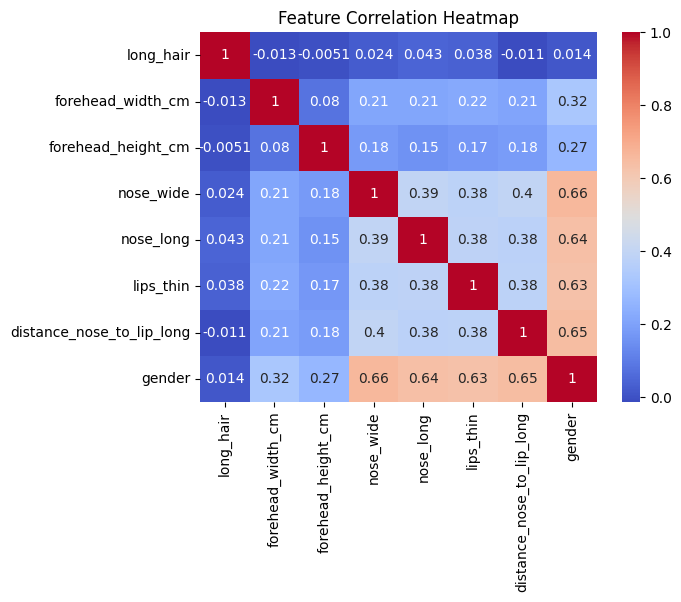

In [10]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

/tmp/ipykernel_1943/211764918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set2')


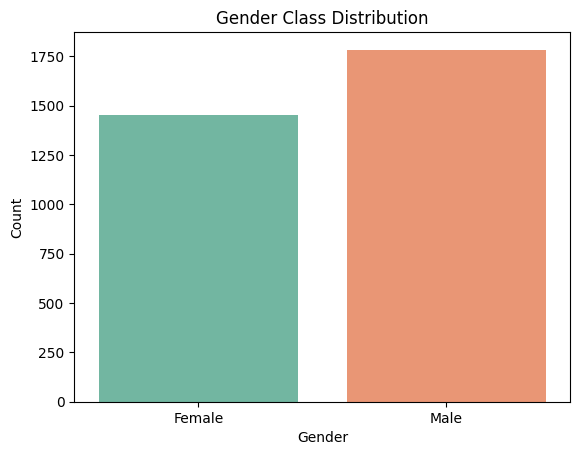

In [11]:
# Class distribution
sns.countplot(x='gender', data=df, palette='Set2')
plt.xticks([0, 1], ['Female', 'Male'])
plt.title("Gender Class Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

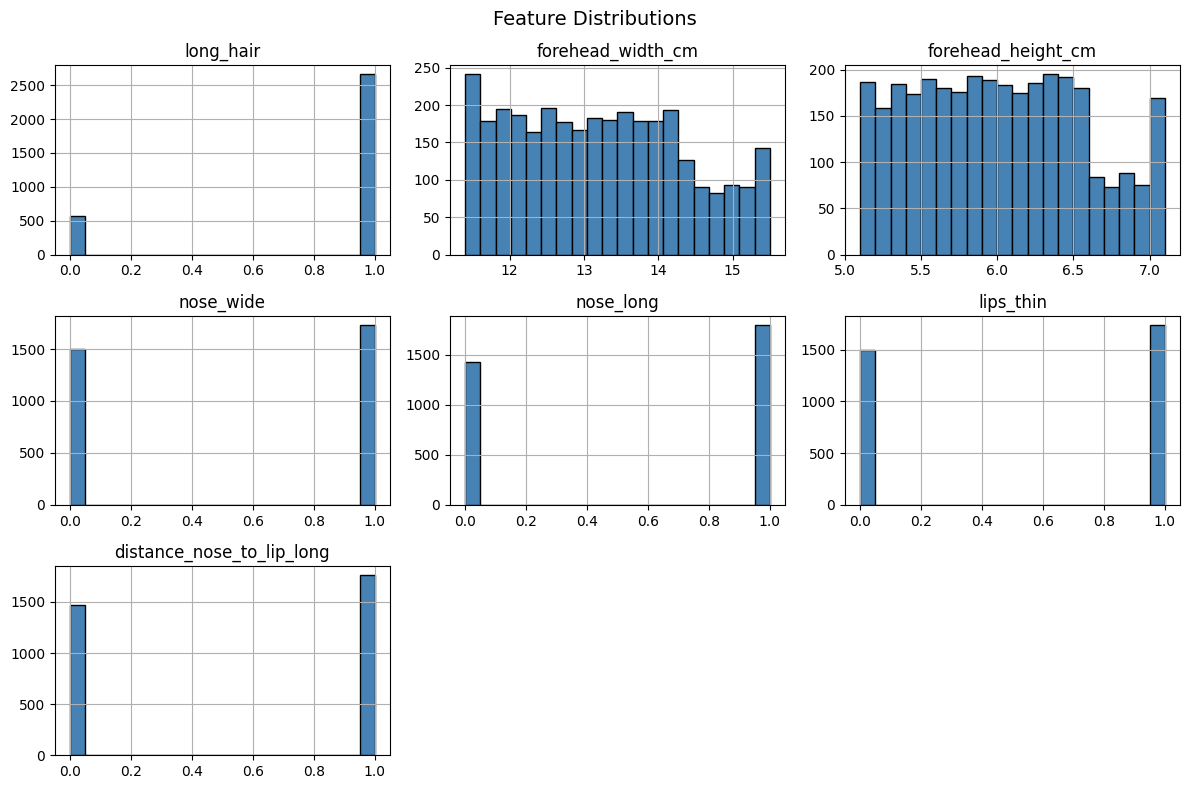

In [12]:
# Feature distributions
df.drop('gender', axis=1).hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

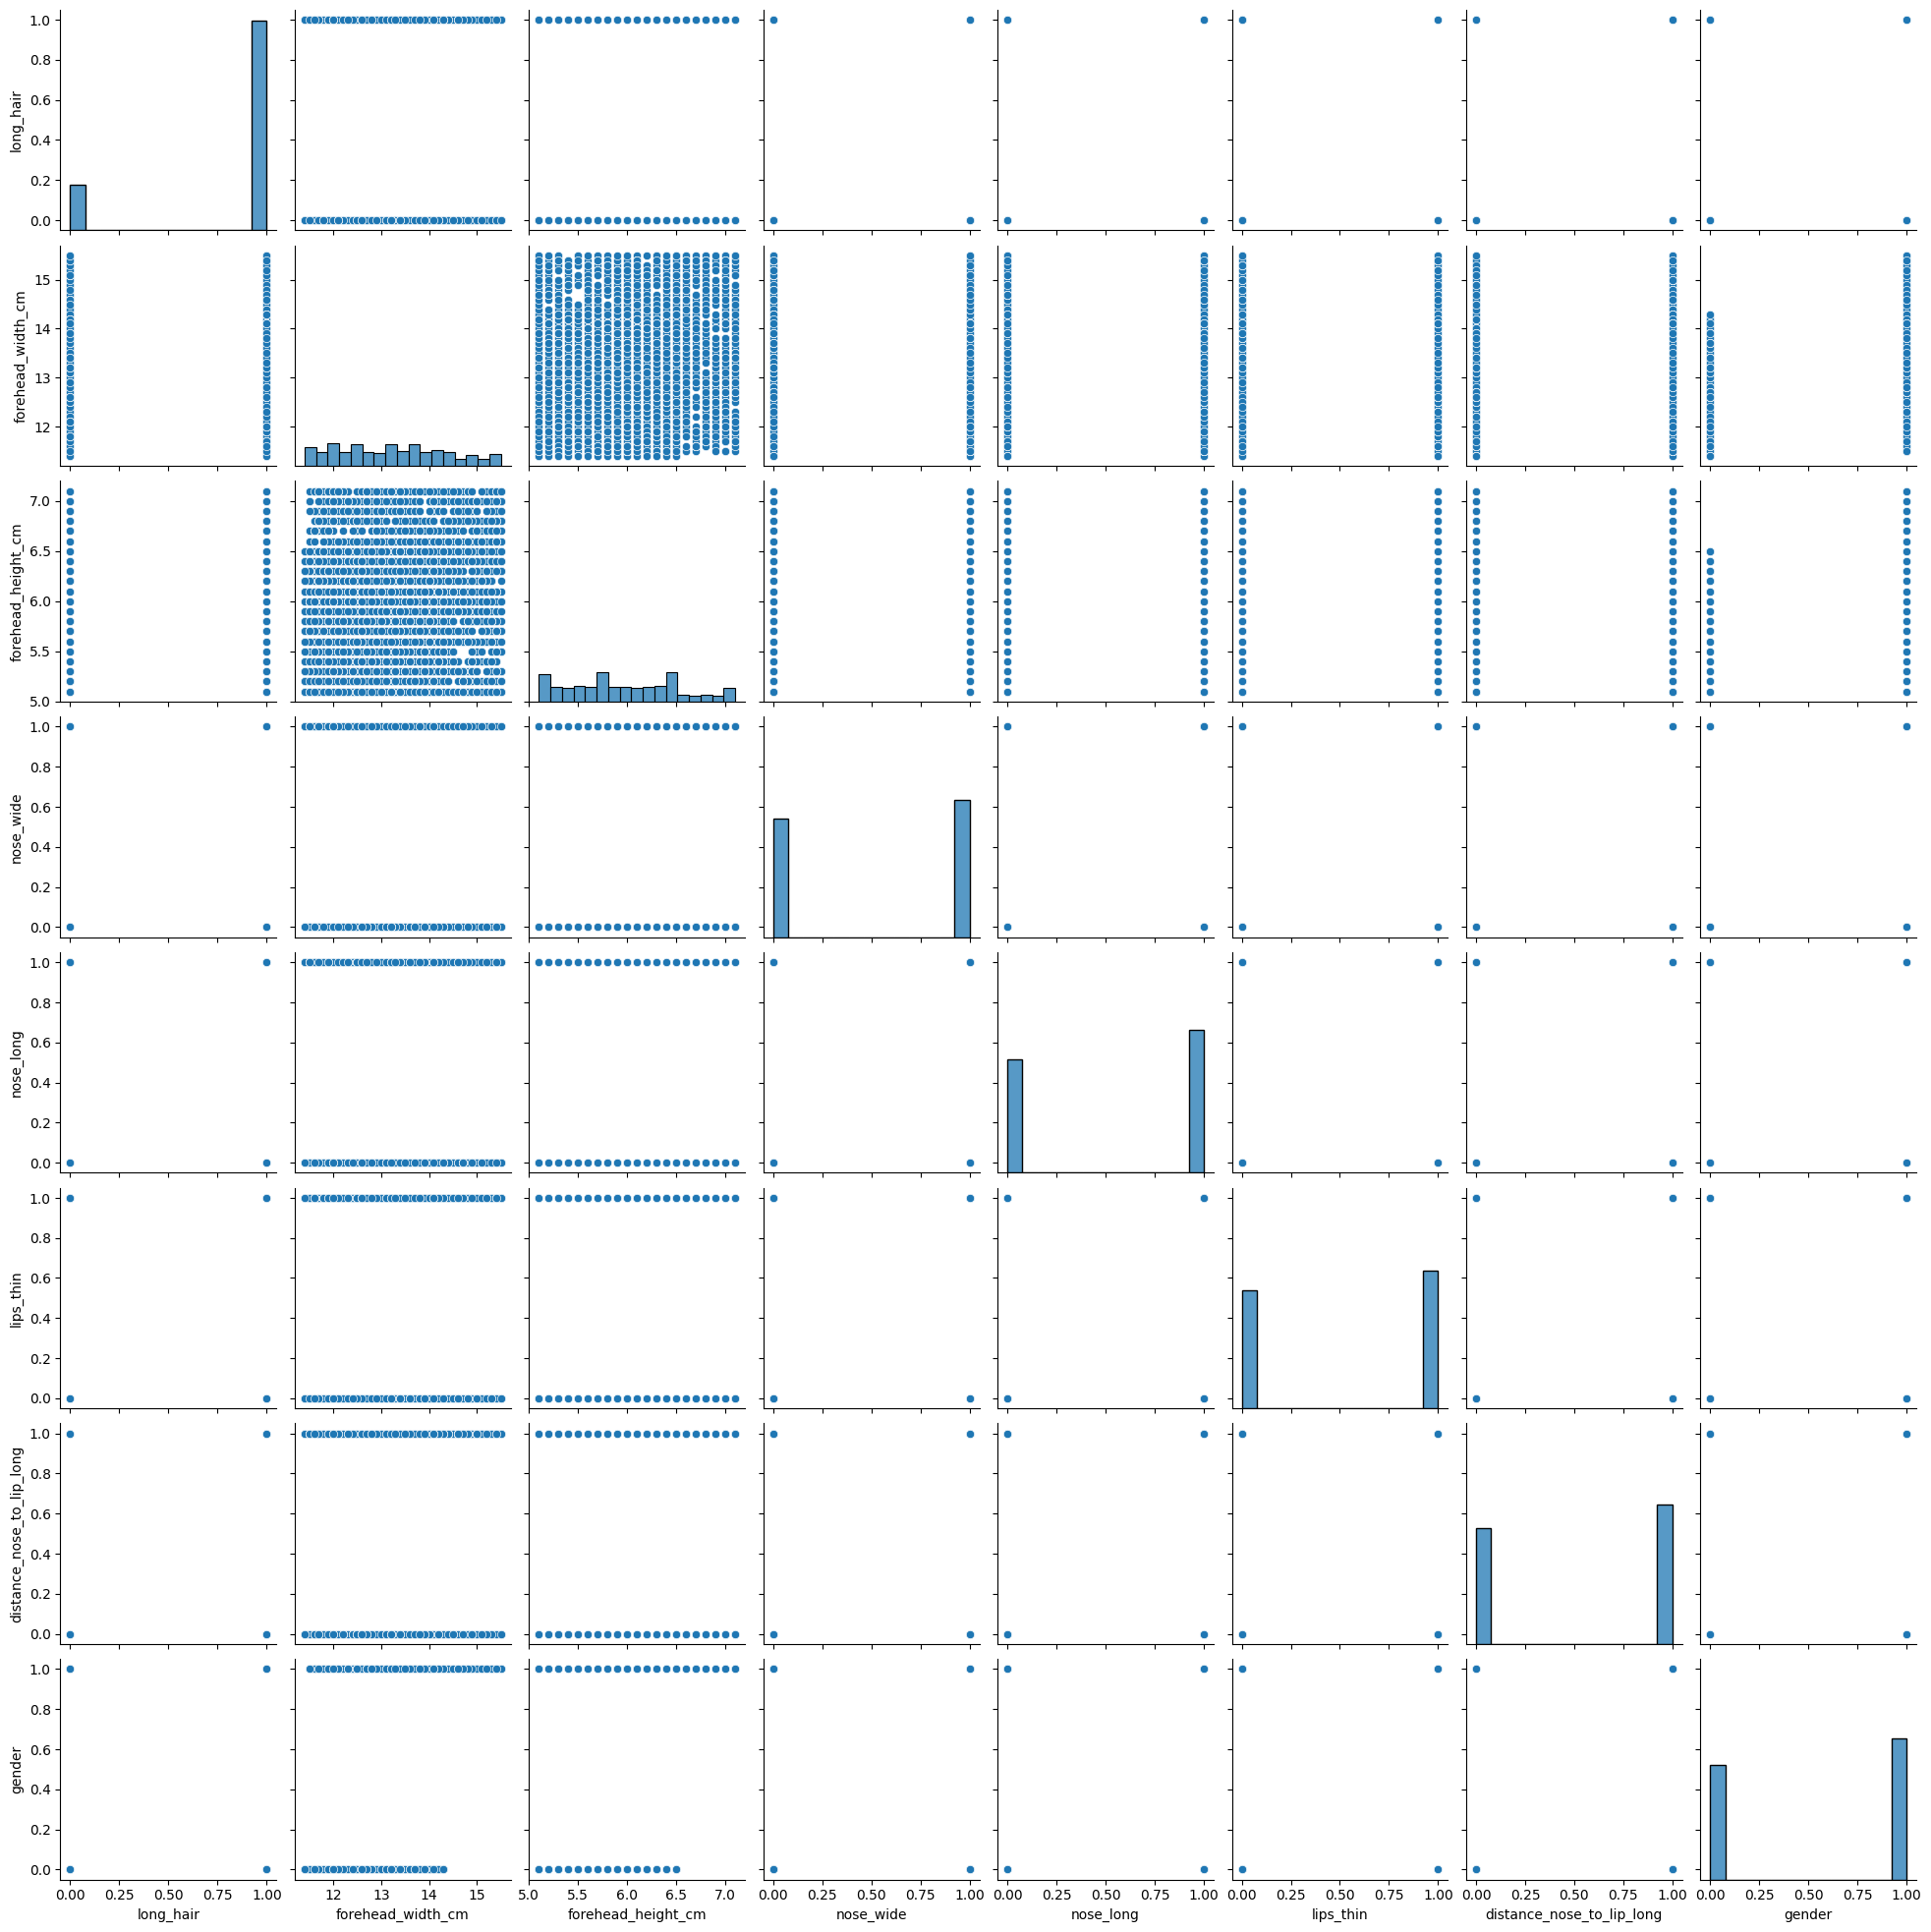

In [13]:
sns.pairplot(df)
plt.show()

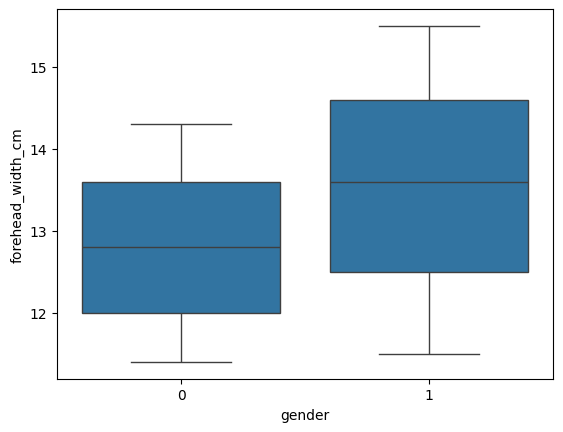

In [14]:
sns.boxplot(x='gender',y='forehead_width_cm',data=df)
plt.show()

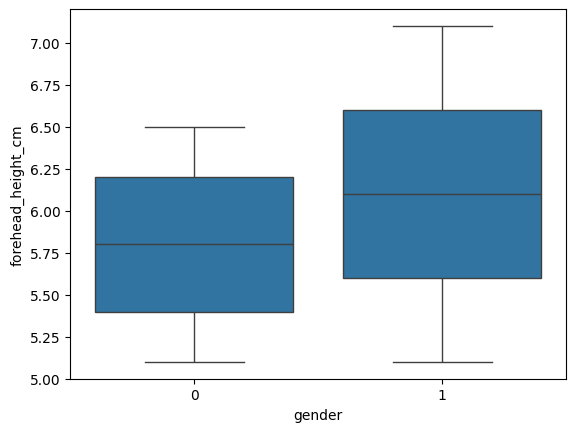

In [15]:
sns.boxplot(x='gender',y='forehead_height_cm',data=df)
plt.show()

# ✂️ 8. Feature Selection, Train-Test Split & Scaling
### We separate features from the target, split the data into training and testing sets (80/20), then apply StandardScaler to normalize the features — this is especially important for distance-based models like KNN and SVM.

In [16]:
X = df.drop('gender', axis=1)
y = df['gender']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 2586
Testing  samples : 647


# 🔵 9. Model 1 — Logistic Regression
### Logistic Regression is a simple yet powerful linear classifier. It models the probability that a sample belongs to a given class.

**Best for:** linearly separable data, fast baseline model.

In [17]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

cv_scores = cross_val_score(lr_model, X_train, y_train, cv=kfold)
print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy       :", cv_scores.mean().round(4))

print("\nAccuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Female', 'Male']))

Cross Validation Scores: [0.94401544 0.9516441  0.93810445 0.95357834 0.97098646]
Mean CV Accuracy       : 0.9517

Accuracy: 0.9428129829984544

Classification Report:
              precision    recall  f1-score   support

      Female       0.95      0.92      0.94       290
        Male       0.94      0.96      0.95       357

    accuracy                           0.94       647
   macro avg       0.94      0.94      0.94       647
weighted avg       0.94      0.94      0.94       647



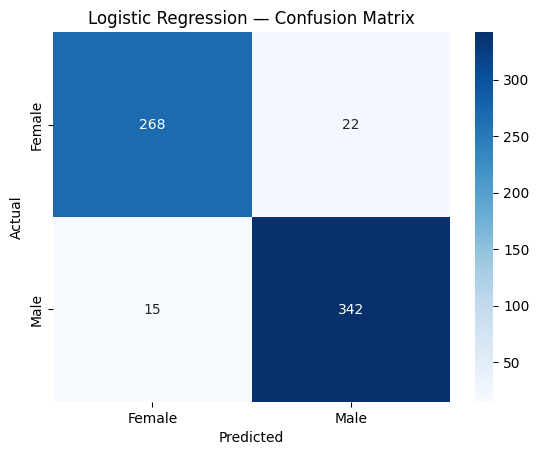

In [18]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Female','Male'], yticklabels=['Female','Male'])
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🌳 10. Model 2 — Decision Tree
### Decision Tree splits the data based on feature thresholds to make predictions. We use Cross-Validation (K-Fold) to evaluate it more robustly and avoid overfitting.

**Best for:** interpretable models, non-linear boundaries.

In [19]:
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(max_depth=3, min_samples_leaf=3, random_state=42))
])

cv_scores = cross_val_score(dt_pipeline, X_train, y_train, cv=kfold)
print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy       :", cv_scores.mean().round(4))

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Female', 'Male']))

Cross Validation Scores: [0.93050193 0.94970986 0.92069632 0.94003868 0.95744681]
Mean CV Accuracy       : 0.9397

Test Accuracy: 0.9397217928902627

Classification Report:
              precision    recall  f1-score   support

      Female       0.94      0.92      0.93       290
        Male       0.94      0.95      0.95       357

    accuracy                           0.94       647
   macro avg       0.94      0.94      0.94       647
weighted avg       0.94      0.94      0.94       647



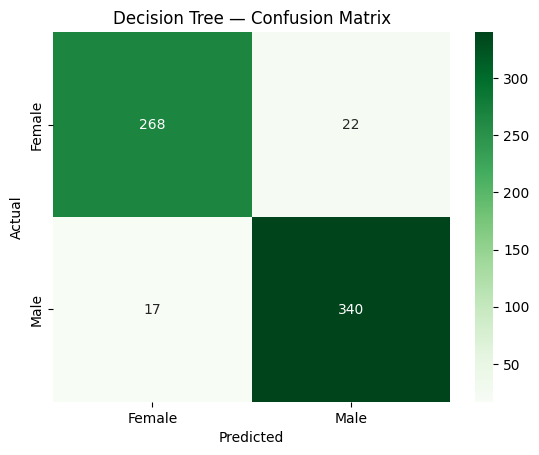

In [20]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['Female','Male'], yticklabels=['Female','Male'])
plt.title("Decision Tree — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

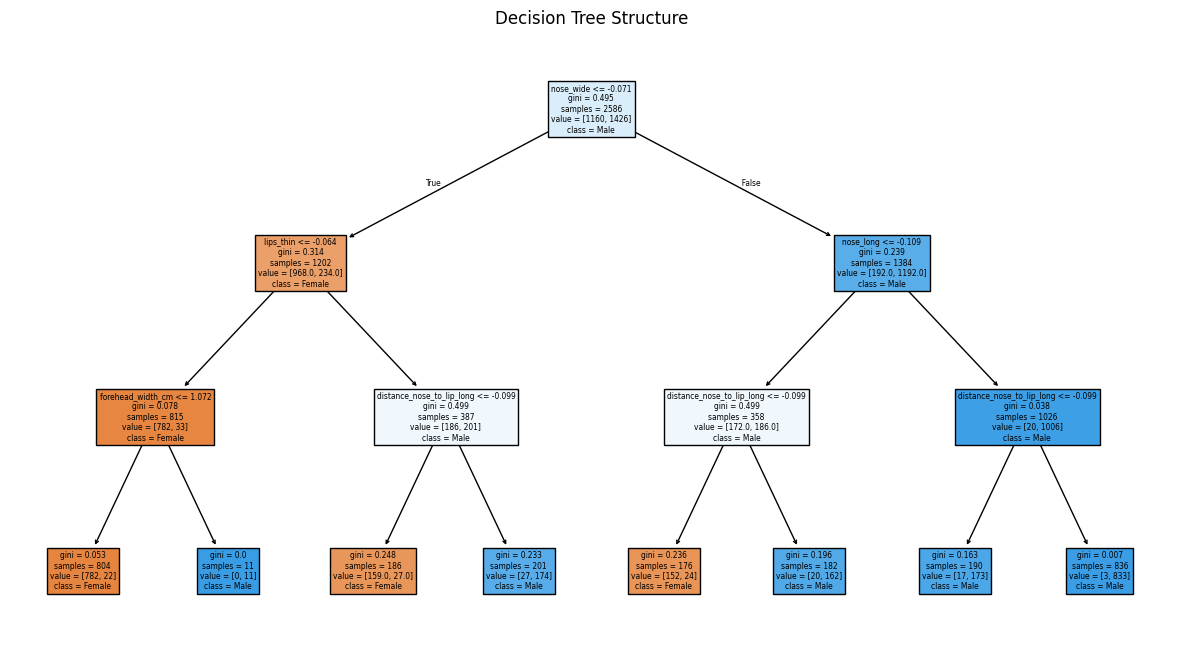

In [21]:
plt.figure(figsize=(15, 8))
plot_tree(
    dt_pipeline.named_steps['model'],
    feature_names=df.drop('gender', axis=1).columns,
    class_names=['Female', 'Male'],
    filled=True
)
plt.title("Decision Tree Structure")
plt.show()

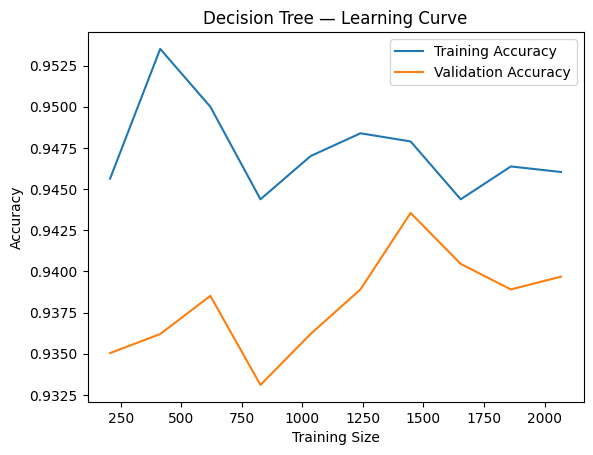

In [22]:
train_sizes, train_scores, test_scores = learning_curve(
    dt_pipeline, X_train, y_train, cv=kfold,
    scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Accuracy")
plt.plot(train_sizes, test_scores.mean(axis=1),  label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Decision Tree — Learning Curve")
plt.legend()
plt.show()

# 🟡 11. Model 3 — Naive Bayes
### Naive Bayes is a probabilistic classifier based on Bayes' theorem. It assumes features are independent from each other.

**Best for:** fast training, works well with small datasets.

In [23]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

cv_scores = cross_val_score(nb_model, X_train, y_train, cv=kfold)
print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy       :", cv_scores.mean().round(4))

print("\nAccuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Female', 'Male']))

Cross Validation Scores: [0.95173745 0.95938104 0.93617021 0.95744681 0.98452611]
Mean CV Accuracy       : 0.9579

Accuracy: 0.9582689335394127

Classification Report:
              precision    recall  f1-score   support

      Female       0.94      0.97      0.95       290
        Male       0.97      0.95      0.96       357

    accuracy                           0.96       647
   macro avg       0.96      0.96      0.96       647
weighted avg       0.96      0.96      0.96       647



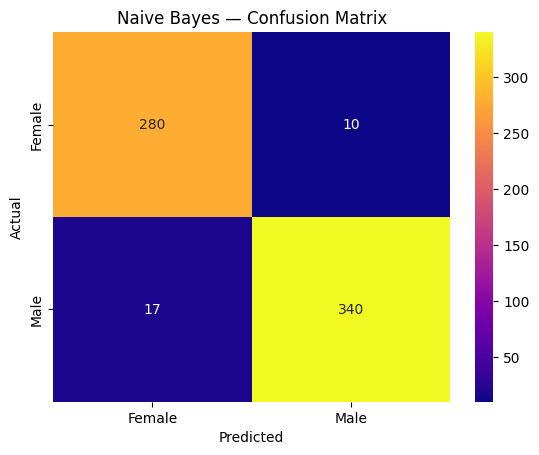

In [24]:
sns.heatmap(confusion_matrix(y_test, y_pred_nb),
            annot=True, fmt='d', cmap='plasma',
            xticklabels=['Female','Male'], yticklabels=['Female','Male'])
plt.title("Naive Bayes — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

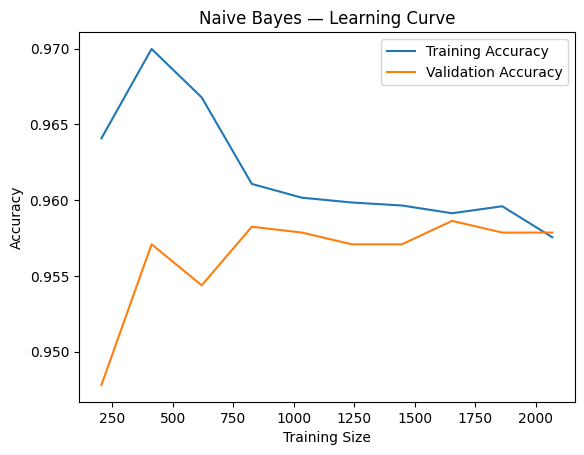

In [25]:
train_sizes, train_scores, test_scores = learning_curve(
    nb_model, X_train, y_train, cv=kfold,
    scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Accuracy")
plt.plot(train_sizes, test_scores.mean(axis=1),  label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Naive Bayes — Learning Curve")
plt.legend()
plt.show()

# 🟠 12. Model 4 — K-Nearest Neighbors (KNN)
### KNN classifies a point based on the majority class among its K nearest neighbors. We also visualize the decision boundary using PCA to reduce features to 2D.

**Best for:** simple non-linear boundaries, small-to-medium datasets.

In [26]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=3))
])

cv_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=kfold)
print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy       :", cv_scores.mean().round(4))

knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Female', 'Male']))

Cross Validation Scores: [0.94208494 0.94777563 0.9303675  0.93810445 0.9729207 ]
Mean CV Accuracy       : 0.9463

Accuracy: 0.9443585780525502

Classification Report:
              precision    recall  f1-score   support

      Female       0.94      0.93      0.94       290
        Male       0.94      0.96      0.95       357

    accuracy                           0.94       647
   macro avg       0.94      0.94      0.94       647
weighted avg       0.94      0.94      0.94       647



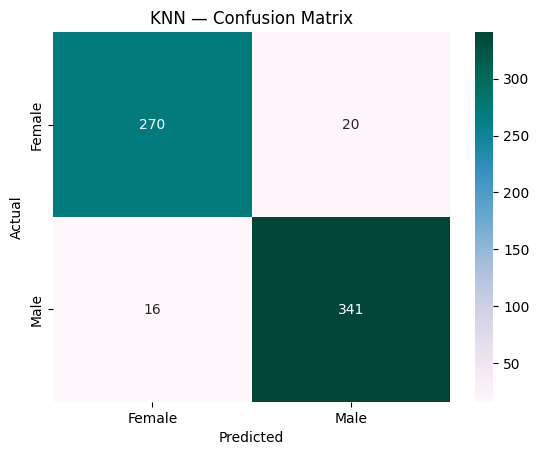

In [27]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn),
            annot=True, fmt='d', cmap='PuBuGn',
            xticklabels=['Female','Male'], yticklabels=['Female','Male'])
plt.title("KNN — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

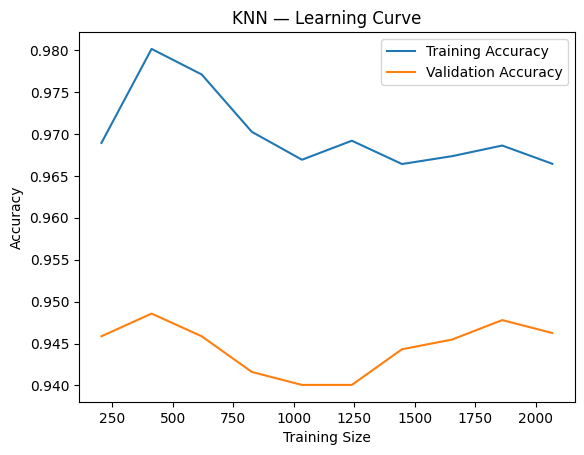

In [28]:
train_sizes, train_scores, test_scores = learning_curve(
    knn_pipeline, X_train, y_train, cv=kfold,
    scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Accuracy")
plt.plot(train_sizes, test_scores.mean(axis=1),  label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("KNN — Learning Curve")
plt.legend()
plt.show()

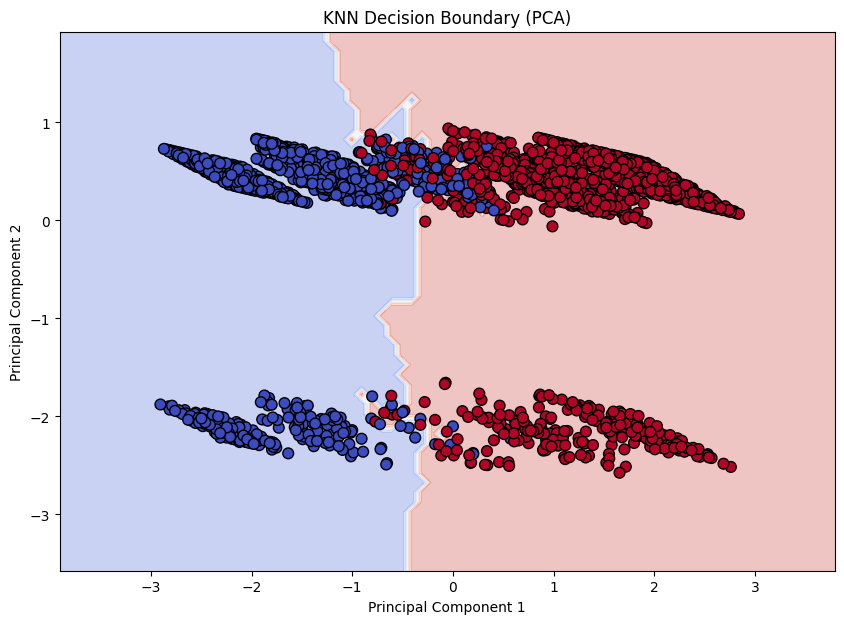

In [29]:
# KNN Decision Boundary using PCA (2D visualization)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

h = 0.1
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            c=y_train, cmap='coolwarm', edgecolors='k', s=60)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KNN Decision Boundary (PCA)")
plt.show()

# 🔴 13. Model 5 — Support Vector Machine (SVM)
### SVM finds the optimal hyperplane that separates classes with the maximum margin. The linear kernel works well when data is linearly separable.

**Best for:** high-dimensional data, robust to outliers.

In [30]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])


cv_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=kfold)
print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy       :", cv_scores.mean().round(4))

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Female', 'Male']))

Cross Validation Scores: [0.94594595 0.94777563 0.93230174 0.9516441  0.96905222]
Mean CV Accuracy       : 0.9493

Accuracy: 0.9412673879443586

Classification Report:
              precision    recall  f1-score   support

      Female       0.95      0.92      0.93       290
        Male       0.94      0.96      0.95       357

    accuracy                           0.94       647
   macro avg       0.94      0.94      0.94       647
weighted avg       0.94      0.94      0.94       647



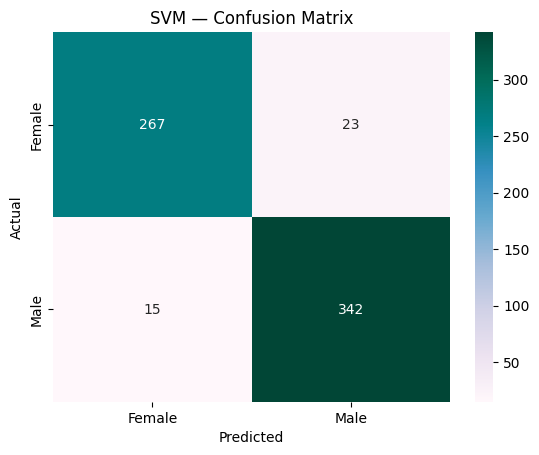

In [31]:
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBuGn',
            xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title("SVM — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

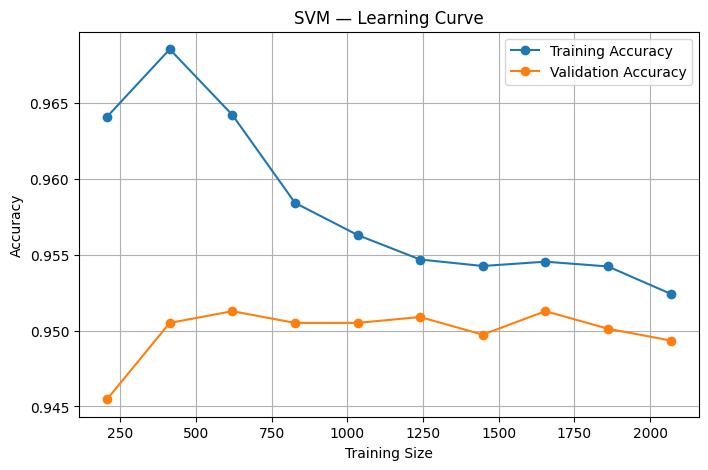

In [32]:
train_sizes, train_scores, test_scores = learning_curve(
    svm_pipeline, X_train, y_train , cv=kfold,
    scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label="Training Accuracy")
plt.plot(train_sizes, test_scores.mean(axis=1),  marker='o', label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("SVM — Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

# 🏆 14. Model Comparison
### After training all five models, we compare their accuracy scores side by side to determine the best performing model on this dataset.

In [33]:
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Naive Bayes',
        'KNN',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
    ]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results['Accuracy'] = results['Accuracy'].round(4)
print(results)
print("\n🏆 Best Model:", results.loc[0, 'Model'],
      "with Accuracy:", results.loc[0, 'Accuracy'])

                 Model  Accuracy
0          Naive Bayes    0.9583
1                  KNN    0.9444
2  Logistic Regression    0.9428
3                  SVM    0.9413
4        Decision Tree    0.9397

🏆 Best Model: Naive Bayes with Accuracy: 0.9583


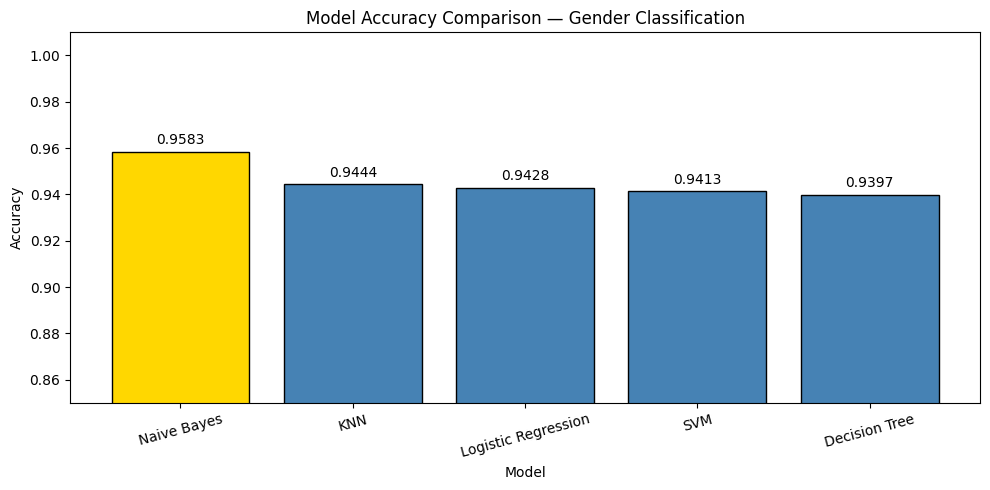

In [34]:
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results))]

plt.figure(figsize=(10, 5))
bars = plt.bar(results['Model'], results['Accuracy'], color=colors, edgecolor='black')

for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f'{acc:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0.85, 1.01)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison — Gender Classification")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [35]:
!pip install gradio -q

In [36]:
import gradio as gr

def predict_gender(
    long_hair,
    forehead_width,
    forehead_height,
    nose_wide,
    nose_long,
    thin_lips,
    distance_nose_to_lip_long
):

    input_data = [[
        long_hair,
        forehead_width,
        forehead_height,
        nose_wide,
        nose_long,
        thin_lips,
        distance_nose_to_lip_long
    ]]

    input_data = scaler.transform(input_data)

    prediction = nb_model.predict(input_data)[0]

    if prediction == 1:
        return "👨 MALE"
    else:
        return "👩 FEMALE"

css = """
.gradio-container{
    max-width:1100px !important;
    margin:auto !important;
    background:white !important;
}

footer{
    display:none;
}

h1{
    text-align:center;
    color:#ff7a00 !important;
    font-size:46px !important;
    font-weight:bold !important;
}

h2,h3,h4,p,li,span,strong{
    color:#222 !important;
}

button{
    background:#ff7a00 !important;
    color:white !important;
    border:none !important;
    border-radius:12px !important;
    font-size:18px !important;
    font-weight:bold !important;
}

button:hover{
    background:#e56d00 !important;
}

.result textarea{
    text-align:center !important;
    font-size:32px !important;
    font-weight:bold !important;
}

.info-card{
    background:#fff3e6;
    padding:20px;
    border-radius:16px;
    margin-bottom:20px;
    border-left:6px solid #ff7a00;
    color:#222 !important;
}

.info-card *{
    color:#222 !important;
}
"""

with gr.Blocks(
    theme=gr.themes.Soft(primary_hue="orange"),
    css=css
) as demo:

    gr.Markdown("""
# 🧠 Gender Classification Using Machine Learning
""")

    gr.HTML("""
    <div class="info-card">

    <h3>🏆 Best Performing Model</h3>

    <p><b>Naive Bayes</b></p>

    <p>📊 Accuracy: <b>95.83%</b></p>

    <p>
    This application predicts gender based on facial characteristics
    using the best-performing machine learning model after comparing
    multiple classification algorithms.
    </p>

    </div>
    """)

    gr.Markdown("""
### 👥 Team Members

- Enas Ibrahim Ali Elnsag
- Malak Tamer Mohamed Ali
- Salma Amer Ahmed Abdel Fattah
- Fatma Mohamed Helmy Mohamed
- Mariem Medhat Afifi
""")

    with gr.Row():
        long_hair = gr.Radio([0,1], label="Long Hair")
        forehead_width = gr.Number(label="Forehead Width (cm)")
        forehead_height = gr.Number(label="Forehead Height (cm)")

    with gr.Row():
        nose_wide = gr.Radio([0,1], label="Nose Wide")
        nose_long = gr.Radio([0,1], label="Nose Long")
        thin_lips = gr.Radio([0,1], label="Thin Lips")
        distance_nose_to_lip_long = gr.Radio(
            [0,1],
            label="Distance Nose To Lip Long"
        )

    predict_btn = gr.Button("🚀 Predict Gender")

    result = gr.Textbox(
        label="Prediction Result",
        lines=2,
        elem_classes="result"
    )

    predict_btn.click(
        fn=predict_gender,
        inputs=[
            long_hair,
            forehead_width,
            forehead_height,
            nose_wide,
            nose_long,
            thin_lips,
            distance_nose_to_lip_long
        ],
        outputs=result
    )

demo.launch(share=True)

/tmp/ipykernel_1943/771394102.py:87: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_1943/771394102.py:87: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ee3dd8315d81111685.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 📝 15. Conclusion

### Summary of Results

In this project, we applied **five classification algorithms** to predict gender based on physical features. Here's a summary of what we found:

| Model | Strengths |
|-------|-----------|
| **Logistic Regression** | Fast, simple, good baseline |
| **Decision Tree** | Interpretable, visual tree structure |
| **Naive Bayes** | Very fast, works well with small data |
| **KNN** | Simple, non-linear boundaries |
| **SVM** | Robust, handles high-dimensional data |

### Key Takeaways
- All models performed well on this dataset due to clear feature separability between genders.
- **StandardScaler** was essential for distance-based models (KNN, SVM).
- **Cross-validation** helped evaluate the Decision Tree more reliably.
- The **Learning Curves** showed no significant overfitting across models.
- The best model was identified in the comparison section above. ☝️
